# 🌍 Global Petrol Market Analytics
### Descriptive · Statistical · Predictive Analysis
**Dataset:** Petrol_Dataset_June_20_2022.csv — 181 Countries · 8 Variables  
**Tools:** pandas · numpy · matplotlib · seaborn · scikit-learn · scipy


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ─────────────────────────────────────────────────────────────
PRIMARY  = '#1B3A6B'
ACCENT1  = '#E84545'
ACCENT2  = '#F5A623'
ACCENT3  = '#27AE60'
LIGHT_BG = '#F7F9FC'
GRID_C   = '#DDE3EC'

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(LIGHT_BG)
    ax.grid(color=GRID_C, linestyle='--', linewidth=0.6, alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold', color=PRIMARY, pad=8)
    ax.set_xlabel(xlabel, fontsize=9, color='#444')
    ax.set_ylabel(ylabel, fontsize=9, color='#444')
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 📥 Load & Preview Dataset

In [2]:
df = pd.read_csv('Petrol_Dataset_June_20_2022.csv', encoding='latin1')
df['World Share (%)'] = df['World Share'].str.replace('%', '').astype(float)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)


Shape: (181, 9)
Columns: ['#', 'Country', 'Daily Oil Consumption (Barrels)', 'World Share', 'Yearly Gallons Per Capita', 'Price Per Gallon (USD)', 'Price Per Liter (USD)', 'Price Per Liter (PKR)', 'World Share (%)']


,#,Country,Daily Oil Consumption (Barrels),World Share,Yearly Gallons Per Capita,Price Per Gallon (USD),Price Per Liter (USD),Price Per Liter (PKR),World Share (%)
0,1,United States,19687287,20.30%,934.3,5.19,1.37,289.97,20.3
1,2,China,12791553,13.20%,138.7,5.42,1.43,302.87,13.2
2,3,India,4443000,4.60%,51.4,5.05,1.33,281.93,4.6
3,4,Japan,4012877,4.10%,481.5,4.69,1.24,262.05,4.1
4,5,Russia,3631287,3.70%,383.2,3.41,0.90,190.56,3.7
5,6,Saudi Arabia,3302000,3.40%,1560.2,2.35,0.62,131.34,3.4
6,7,Brazil,2984000,3.10%,221.9,5.36,1.42,299.27,3.1
7,8,South Korea,2605440,2.70%,783.4,6.09,1.61,340.52,2.7
8,9,Canada,2486301,2.60%,1047.6,6.76,1.79,377.74,2.6
9,10,Germany,2383393,2.50%,444.5,7.65,2.02,427.44,2.5


In [3]:
# Quick data health check
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())


Data Types:
#                                    int64
Country                             object
Daily Oil Consumption (Barrels)      int64
World Share                         object
Yearly Gallons Per Capita          float64
Price Per Gallon (USD)             float64
Price Per Liter (USD)              float64
Price Per Liter (PKR)              float64
World Share (%)                    float64
dtype: object

Missing Values:
#                                  0
Country                            0
Daily Oil Consumption (Barrels)    0
World Share                        0
Yearly Gallons Per Capita          0
Price Per Gallon (USD)             0
Price Per Liter (USD)              0
Price Per Liter (PKR)              0
World Share (%)                    0
dtype: int64


---
## 📊 SECTION 1 — Descriptive Analytics
> Descriptive analytics summarises what the data shows — patterns, distributions, rankings, and shares.


### Q1 | Which countries consume the most oil daily?

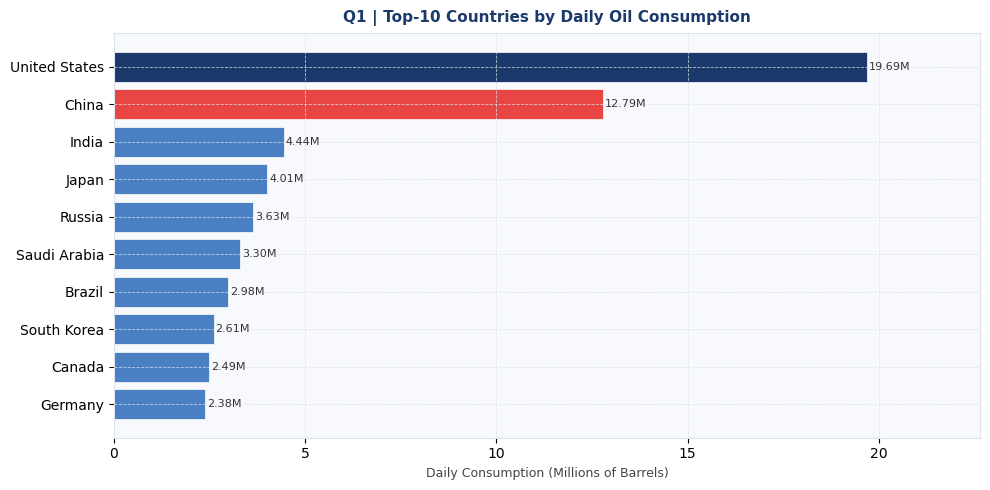


Top consumer: United States at 19,687,287 barrels/day


In [4]:
top10 = df.nlargest(10, 'Daily Oil Consumption (Barrels)')
colors = [PRIMARY if i == 0 else ACCENT1 if i == 1 else '#4A7FC1' for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['Country'][::-1],
               top10['Daily Oil Consumption (Barrels)'][::-1] / 1e6,
               color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}M', va='center', fontsize=8, color='#333')
style_ax(ax,
    title='Q1 | Top-10 Countries by Daily Oil Consumption',
    xlabel='Daily Consumption (Millions of Barrels)', ylabel='')
ax.set_xlim(0, top10['Daily Oil Consumption (Barrels)'].max()/1e6 * 1.15)
plt.tight_layout()
plt.show()

print(f"\nTop consumer: {top10.iloc[0]['Country']} at {top10.iloc[0]['Daily Oil Consumption (Barrels)']:,.0f} barrels/day")


### Q2 | How are petrol prices globally distributed?

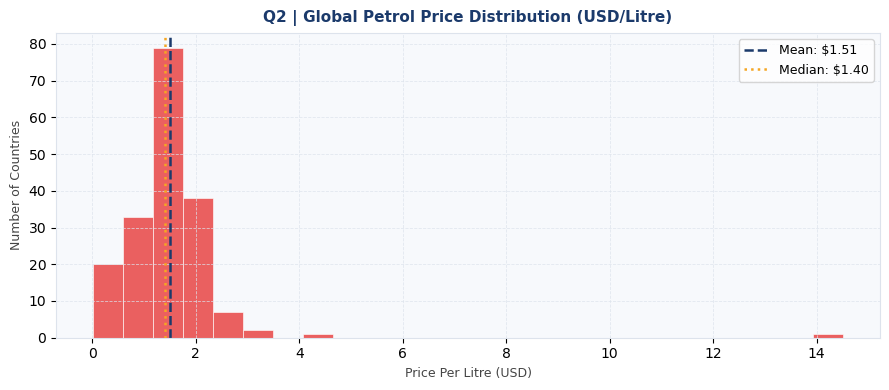

Mean:   $1.505
Median: $1.400
Std:    $1.155
Min:    $0.020  (Venezuela)
Max:    $14.500  (North Korea)


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Price Per Liter (USD)'], bins=25, color=ACCENT1,
        edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df['Price Per Liter (USD)'].mean(), color=PRIMARY, linewidth=1.8,
           linestyle='--', label=f'Mean: ${df["Price Per Liter (USD)"].mean():.2f}')
ax.axvline(df['Price Per Liter (USD)'].median(), color=ACCENT2, linewidth=1.8,
           linestyle=':', label=f'Median: ${df["Price Per Liter (USD)"].median():.2f}')
ax.legend(fontsize=9)
style_ax(ax,
    title='Q2 | Global Petrol Price Distribution (USD/Litre)',
    xlabel='Price Per Litre (USD)', ylabel='Number of Countries')
plt.tight_layout()
plt.show()

print(f"Mean:   ${df['Price Per Liter (USD)'].mean():.3f}")
print(f"Median: ${df['Price Per Liter (USD)'].median():.3f}")
print(f"Std:    ${df['Price Per Liter (USD)'].std():.3f}")
print(f"Min:    ${df['Price Per Liter (USD)'].min():.3f}  ({df.loc[df['Price Per Liter (USD)'].idxmin(),'Country']})")
print(f"Max:    ${df['Price Per Liter (USD)'].max():.3f}  ({df.loc[df['Price Per Liter (USD)'].idxmax(),'Country']})")


### Q3 | Which countries have the cheapest and most expensive petrol?

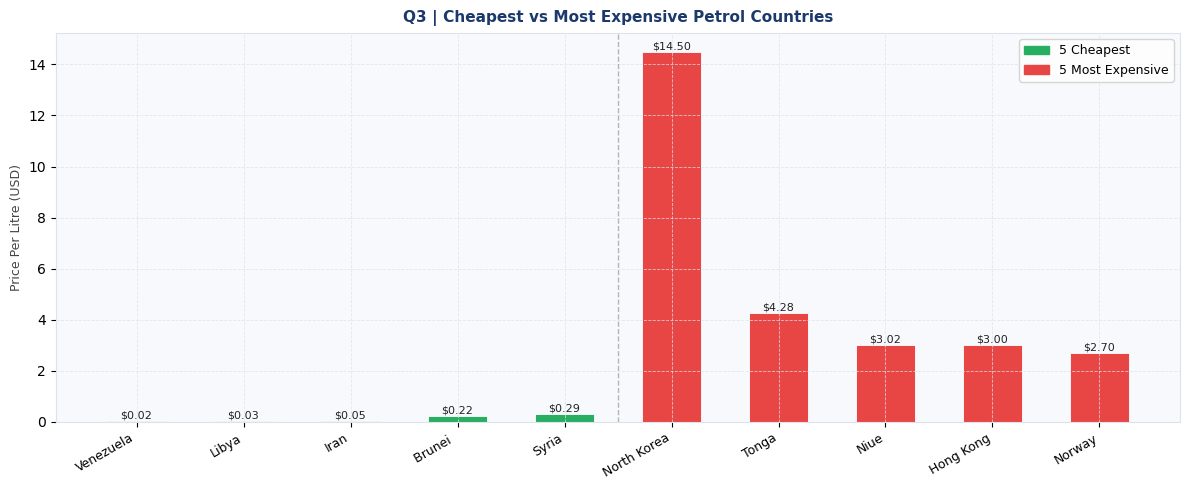

In [6]:
top5_cheap = df.nsmallest(5, 'Price Per Liter (USD)')[['Country','Price Per Liter (USD)']].assign(Group='5 Cheapest')
top5_exp   = df.nlargest(5,  'Price Per Liter (USD)')[['Country','Price Per Liter (USD)']].assign(Group='5 Most Expensive')
combined   = pd.concat([top5_cheap, top5_exp])
bar_colors = [ACCENT3]*5 + [ACCENT1]*5
x_pos      = range(len(combined))

fig, ax = plt.subplots(figsize=(12, 5))
bars3 = ax.bar(x_pos, combined['Price Per Liter (USD)'],
               color=bar_colors, edgecolor='white', linewidth=0.6, width=0.55)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(combined['Country'], rotation=30, ha='right', fontsize=9)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'${bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, color='#222')
ax.axvline(4.5, color='#999', linestyle='--', linewidth=1, alpha=0.7)
green_patch = mpatches.Patch(color=ACCENT3, label='5 Cheapest')
red_patch   = mpatches.Patch(color=ACCENT1, label='5 Most Expensive')
ax.legend(handles=[green_patch, red_patch], fontsize=9)
style_ax(ax,
    title='Q3 | Cheapest vs Most Expensive Petrol Countries',
    xlabel='', ylabel='Price Per Litre (USD)')
plt.tight_layout()
plt.show()


### Q4 | What share of global oil does each top country consume?

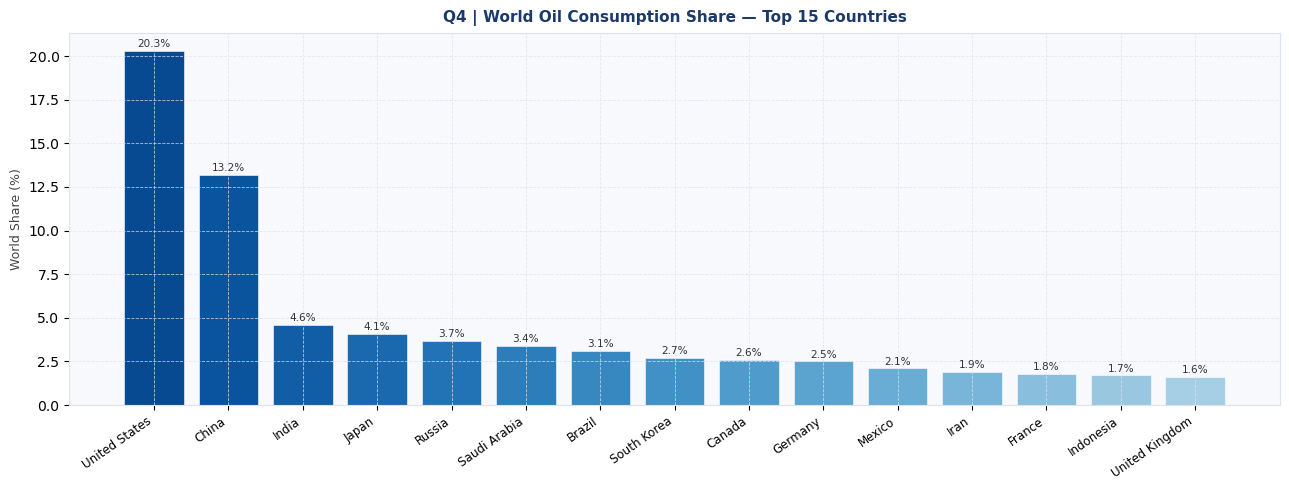

Top 5 combined share: 45.9 %


In [7]:
top15 = df.nlargest(15, 'World Share (%)').reset_index(drop=True)
palette = plt.cm.Blues(np.linspace(0.35, 0.9, 15))[::-1]

fig, ax = plt.subplots(figsize=(13, 5))
bars4 = ax.bar(range(15), top15['World Share (%)'], color=palette, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(15))
ax.set_xticklabels(top15['Country'], rotation=35, ha='right', fontsize=8.5)
for bar in bars4:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, color='#333')
style_ax(ax,
    title='Q4 | World Oil Consumption Share — Top 15 Countries',
    xlabel='', ylabel='World Share (%)')
plt.tight_layout()
plt.show()

top5_share = top15.head(5)[['Country','World Share (%)']].set_index('Country')
print("Top 5 combined share:", top5_share['World Share (%)'].sum().round(2), "%")


### Q5 | Spread of annual petrol consumption per person

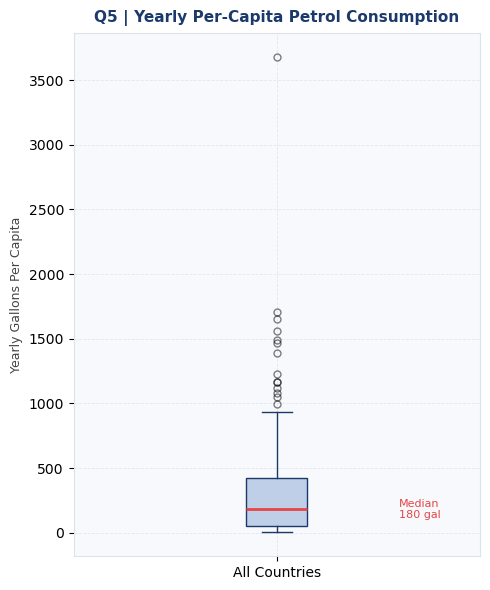

Q1: 54 gal | Median: 180 gal | Q3: 425 gal | IQR: 371 gal


In [8]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.boxplot(df['Yearly Gallons Per Capita'].dropna(),
           patch_artist=True,
           boxprops=dict(facecolor='#BFCFE7', color=PRIMARY),
           medianprops=dict(color=ACCENT1, linewidth=2),
           whiskerprops=dict(color=PRIMARY), capprops=dict(color=PRIMARY),
           flierprops=dict(marker='o', color=ACCENT2, alpha=0.5, markersize=5))
ax.set_xticklabels(['All Countries'])
q25, q50, q75 = (df['Yearly Gallons Per Capita'].quantile(0.25),
                 df['Yearly Gallons Per Capita'].quantile(0.50),
                 df['Yearly Gallons Per Capita'].quantile(0.75))
ax.text(1.3, q50, f'Median\n{q50:.0f} gal', va='center', fontsize=8, color=ACCENT1)
style_ax(ax,
    title='Q5 | Yearly Per-Capita Petrol Consumption',
    ylabel='Yearly Gallons Per Capita')
plt.tight_layout()
plt.show()

print(f"Q1: {q25:.0f} gal | Median: {q50:.0f} gal | Q3: {q75:.0f} gal | IQR: {q75-q25:.0f} gal")


### Q6 | Petrol metrics heatmap — Top 20 consuming countries

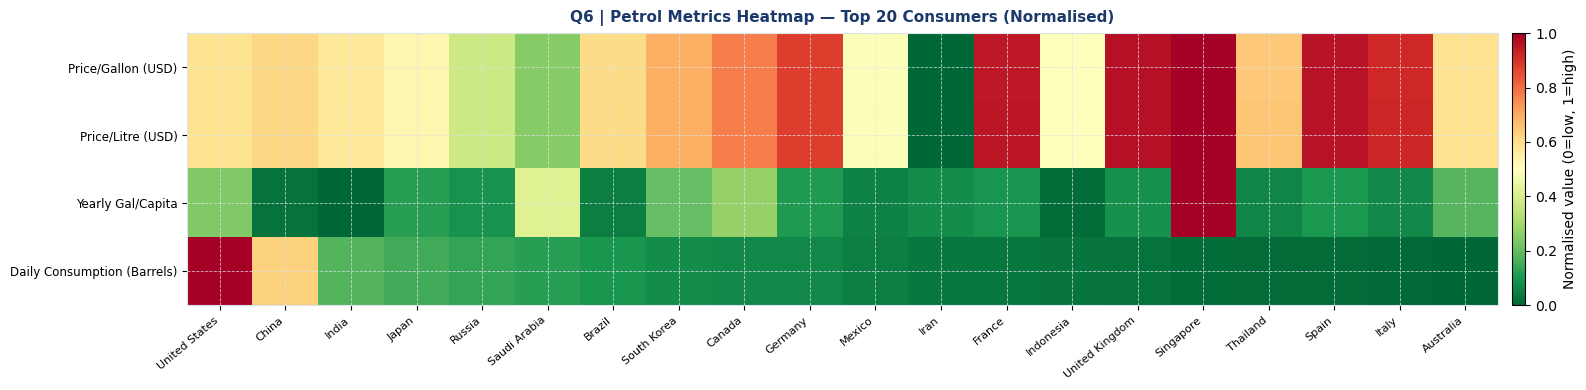

In [9]:
top20 = df.nlargest(20, 'Daily Oil Consumption (Barrels)').reset_index(drop=True)
heat_data = top20[['Price Per Gallon (USD)', 'Price Per Liter (USD)',
                    'Yearly Gallons Per Capita', 'Daily Oil Consumption (Barrels)']].copy()
heat_data.columns = ['Price/Gallon (USD)', 'Price/Litre (USD)',
                     'Yearly Gal/Capita', 'Daily Consumption (Barrels)']
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(heat_norm.T, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(20))
ax.set_xticklabels(top20['Country'], rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(4))
ax.set_yticklabels(heat_norm.columns, fontsize=8.5)
plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.015, pad=0.01,
             label='Normalised value (0=low, 1=high)')
style_ax(ax, title='Q6 | Petrol Metrics Heatmap — Top 20 Consumers (Normalised)')
plt.tight_layout()
plt.show()


---
## 📐 SECTION 2 — Statistical Analytics
> Quantify relationships, measure variability, detect anomalies, and test the strength of associations.


### Q7 | How strongly are the petrol metrics correlated?

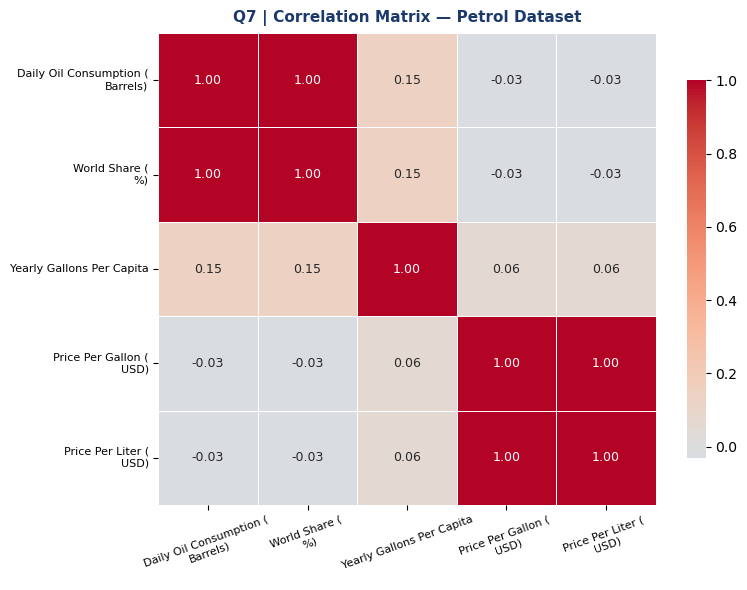

Correlation with Price Per Liter (USD):
Daily Oil Consumption (Barrels)   -0.030106
World Share (%)                   -0.029353
Yearly Gallons Per Capita          0.057471
Price Per Gallon (USD)             0.999997
Name: Price Per Liter (USD), dtype: float64


In [10]:
num_cols = ['Daily Oil Consumption (Barrels)', 'World Share (%)',
            'Yearly Gallons Per Capita', 'Price Per Gallon (USD)', 'Price Per Liter (USD)']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_xticklabels([c.replace('(', '(\n') for c in corr.columns], fontsize=8, rotation=20)
ax.set_yticklabels([c.replace('(', '(\n') for c in corr.index], fontsize=8, rotation=0)
ax.set_title('Q7 | Correlation Matrix — Petrol Dataset', fontsize=11,
             fontweight='bold', color=PRIMARY, pad=8)
plt.tight_layout()
plt.show()

print("Correlation with Price Per Liter (USD):")
print(corr['Price Per Liter (USD)'].drop('Price Per Liter (USD)').sort_values())


### Q8 | Key descriptive statistics summary

In [11]:
stats_summary = df[['Daily Oil Consumption (Barrels)',
                     'Yearly Gallons Per Capita',
                     'Price Per Liter (USD)',
                     'World Share (%)']].describe().round(3)
stats_summary


,Daily Oil Consumption (Barrels),Yearly Gallons Per Capita,Price Per Liter (USD),World Share (%)
count,1.810000e+02,181.000,181.000,181.000
mean,5.335731e+05,332.007,1.505,0.550
std,1.858067e+06,436.559,1.155,1.917
min,5.100000e+01,2.200,0.020,0.000
25%,2.003600e+04,53.900,1.100,0.020
50%,6.161200e+04,180.200,1.400,0.060
75%,2.623520e+05,424.600,1.790,0.300
max,1.968729e+07,3679.500,14.500,20.300


### Q9 | Which countries are statistical outliers in petrol price? (Z-score)

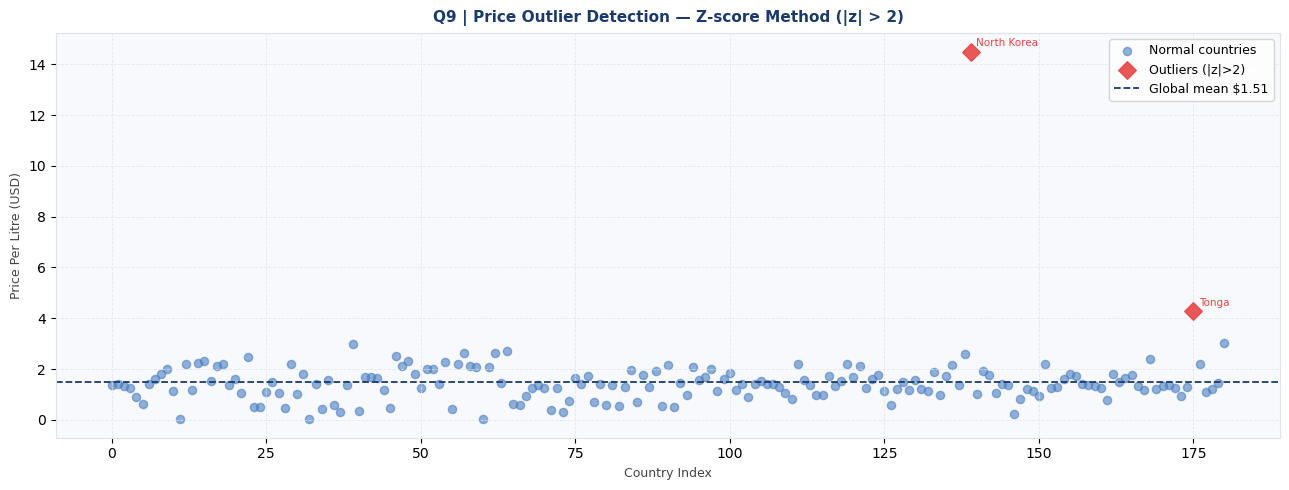

Number of outlier countries: 2
    Country  Price Per Liter (USD)
North Korea                  14.50
      Tonga                   4.28


In [12]:
z_scores = np.abs(stats.zscore(df['Price Per Liter (USD)']))
outliers = df[z_scores > 2].copy()
normal   = df[z_scores <= 2].copy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(normal.index, normal['Price Per Liter (USD)'],
           color='#4A7FC1', alpha=0.6, s=35, label='Normal countries')
ax.scatter(outliers.index, outliers['Price Per Liter (USD)'],
           color=ACCENT1, alpha=0.9, s=80, marker='D', label='Outliers (|z|>2)', zorder=5)
for _, row in outliers.iterrows():
    ax.annotate(row['Country'], (row.name, row['Price Per Liter (USD)']),
                textcoords='offset points', xytext=(4, 4), fontsize=7.5, color=ACCENT1)
ax.axhline(df['Price Per Liter (USD)'].mean(), color=PRIMARY,
           linestyle='--', linewidth=1.3, label=f'Global mean ${df["Price Per Liter (USD)"].mean():.2f}')
style_ax(ax,
    title='Q9 | Price Outlier Detection — Z-score Method (|z| > 2)',
    xlabel='Country Index', ylabel='Price Per Litre (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Number of outlier countries: {len(outliers)}")
print(outliers[['Country','Price Per Liter (USD)']].to_string(index=False))


### Q10 | Is there a link between daily oil consumption and petrol price?

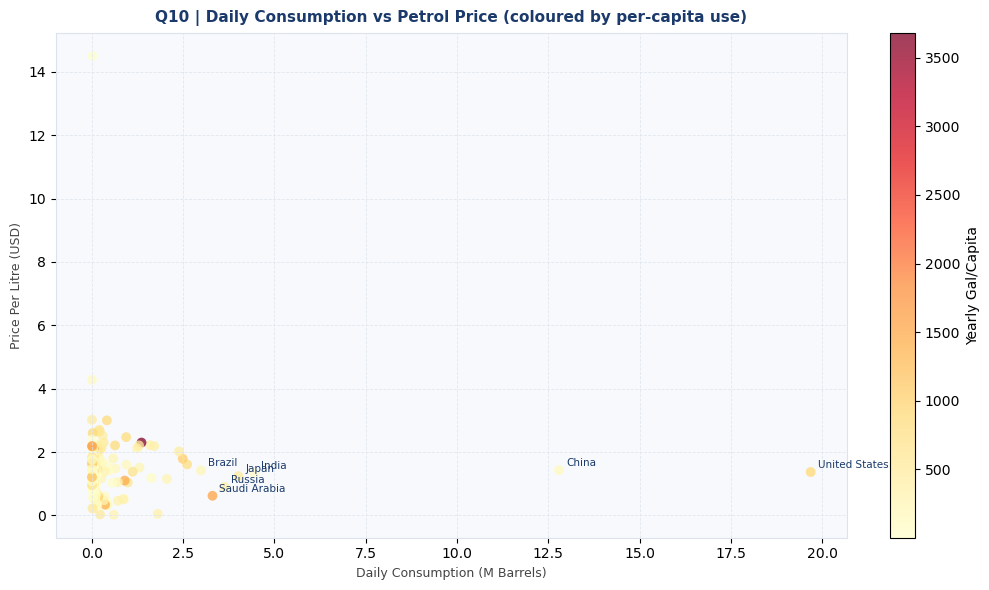

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['Daily Oil Consumption (Barrels)'] / 1e6,
                df['Price Per Liter (USD)'],
                c=df['Yearly Gallons Per Capita'],
                cmap='YlOrRd', s=50, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Yearly Gal/Capita', fraction=0.03)
for _, row in df.nlargest(7, 'Daily Oil Consumption (Barrels)').iterrows():
    ax.annotate(row['Country'],
                (row['Daily Oil Consumption (Barrels)']/1e6, row['Price Per Liter (USD)']),
                textcoords='offset points', xytext=(5, 3), fontsize=7.5, color=PRIMARY)
style_ax(ax,
    title='Q10 | Daily Consumption vs Petrol Price (coloured by per-capita use)',
    xlabel='Daily Consumption (M Barrels)', ylabel='Price Per Litre (USD)')
plt.tight_layout()
plt.show()


### Q11 | How many countries fall in each price band? (IQR Quartile method)

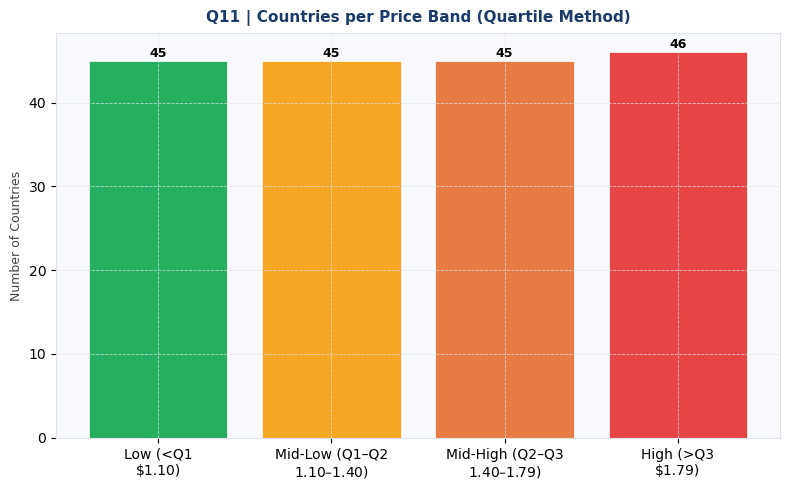

IQR: $0.690  |  Q1=$1.100  Q2=1.400  Q3=1.790


In [14]:
price = df['Price Per Liter (USD)']
q1, q2, q3 = price.quantile([0.25, 0.5, 0.75])
bands = {
    f'Low (<Q1\n${q1:.2f})':             (price < q1).sum(),
    f'Mid-Low (Q1–Q2\n${q1:.2f}–${q2:.2f})': ((price>=q1)&(price<q2)).sum(),
    f'Mid-High (Q2–Q3\n${q2:.2f}–${q3:.2f})':((price>=q2)&(price<q3)).sum(),
    f'High (>Q3\n${q3:.2f})':             (price >= q3).sum()
}
bcolors = [ACCENT3, ACCENT2, '#E87C45', ACCENT1]

fig, ax = plt.subplots(figsize=(8, 5))
bars11 = ax.bar(bands.keys(), bands.values(), color=bcolors, edgecolor='white', linewidth=0.5)
for bar in bars11:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')
style_ax(ax,
    title='Q11 | Countries per Price Band (Quartile Method)',
    ylabel='Number of Countries')
plt.tight_layout()
plt.show()

print(f"IQR: ${q3-q1:.3f}  |  Q1=${q1:.3f}  Q2={q2:.3f}  Q3={q3:.3f}")


### Q12 | Does per-capita consumption predict petrol price? (OLS Regression)

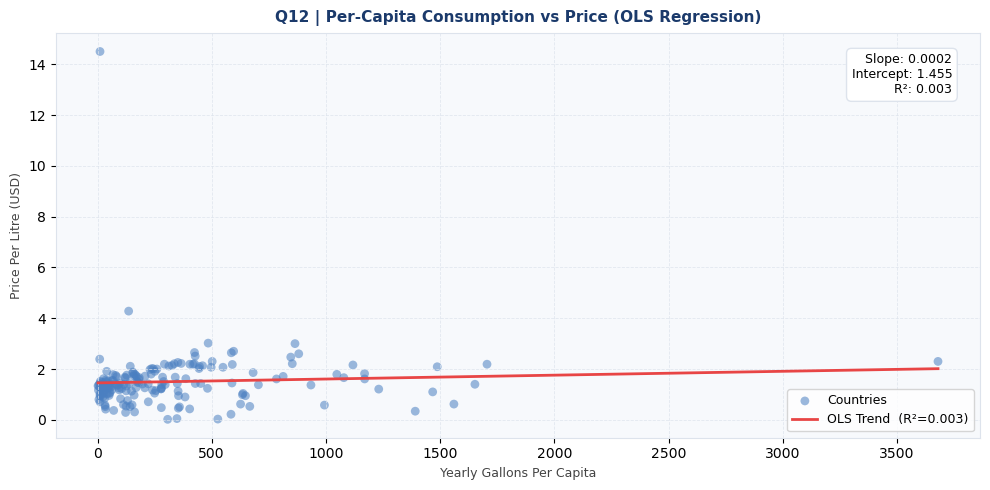

Slope: 0.00015  |  Intercept: 1.4547  |  R²: 0.0033
Trend direction: positive


In [15]:
x12 = df['Yearly Gallons Per Capita'].values.reshape(-1, 1)
y12 = df['Price Per Liter (USD)'].values
reg  = LinearRegression().fit(x12, y12)
xline = np.linspace(x12.min(), x12.max(), 200).reshape(-1,1)
r2 = r2_score(y12, reg.predict(x12))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Yearly Gallons Per Capita'], df['Price Per Liter (USD)'],
           color='#4A7FC1', alpha=0.55, s=40, edgecolors='none', label='Countries')
ax.plot(xline, reg.predict(xline), color=ACCENT1, linewidth=2,
        label=f'OLS Trend  (R²={r2:.3f})')
slope_dir = 'negative' if reg.coef_[0] < 0 else 'positive'
ax.text(0.97, 0.95,
        f'Slope: {reg.coef_[0]:.4f}\nIntercept: {reg.intercept_:.3f}\nR²: {r2:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=GRID_C))
style_ax(ax,
    title='Q12 | Per-Capita Consumption vs Price (OLS Regression)',
    xlabel='Yearly Gallons Per Capita', ylabel='Price Per Litre (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Slope: {reg.coef_[0]:.5f}  |  Intercept: {reg.intercept_:.4f}  |  R²: {r2:.4f}")
print(f"Trend direction: {slope_dir}")


---
## 🔮 SECTION 3 — Predictive Analytics
> Apply machine-learning and statistical modelling to forecast outcomes and classify countries into meaningful groups.


### Q13 | How do countries cluster by consumption, price & per-capita use? (K-Means)

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


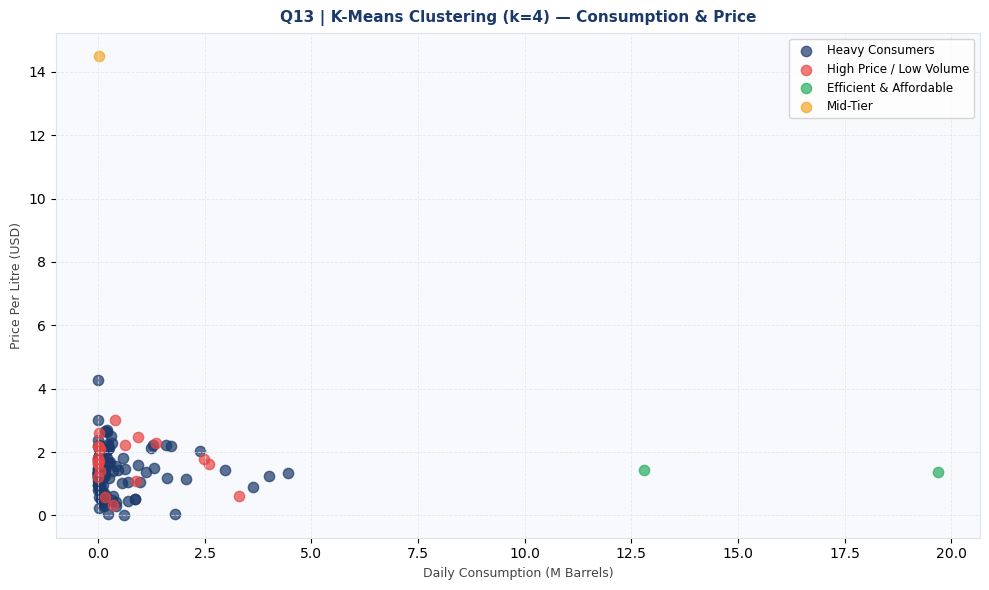

Cluster assignments:
Cluster
0    [India, Japan, Russia, Brazil, Germany, Mexico...
1    [Saudi Arabia, South Korea, Canada, Singapore,...
2                               [United States, China]
3                                        [North Korea]
Name: Country, dtype: object


In [16]:
feats = df[['Daily Oil Consumption (Barrels)', 'Price Per Liter (USD)',
            'Yearly Gallons Per Capita']].fillna(0)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(feats)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_sc)

cluster_colors = {0: PRIMARY, 1: ACCENT1, 2: ACCENT3, 3: ACCENT2}
cluster_labels = {0: 'Heavy Consumers', 1: 'High Price / Low Volume',
                  2: 'Efficient & Affordable', 3: 'Mid-Tier'}

fig, ax = plt.subplots(figsize=(10, 6))
for cl, grp in df.groupby('Cluster'):
    ax.scatter(grp['Daily Oil Consumption (Barrels)']/1e6,
               grp['Price Per Liter (USD)'],
               color=cluster_colors[cl], alpha=0.7, s=55, label=cluster_labels[cl])
style_ax(ax,
    title='Q13 | K-Means Clustering (k=4) — Consumption & Price',
    xlabel='Daily Consumption (M Barrels)', ylabel='Price Per Litre (USD)')
ax.legend(fontsize=8.5, loc='upper right')
plt.tight_layout()
plt.show()

print("Cluster assignments:")
print(df.groupby('Cluster')['Country'].apply(list))


### Q14 | How many countries are in each cluster?

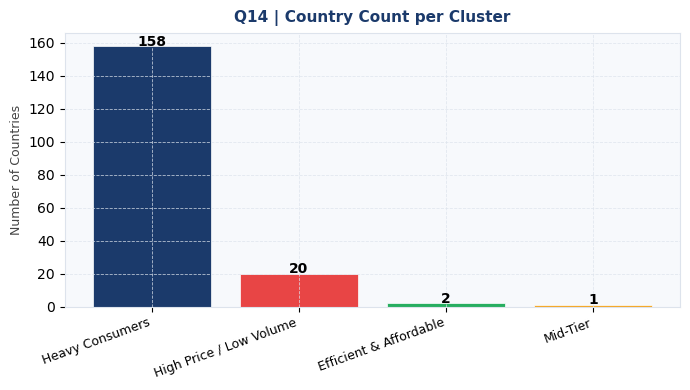

Cluster
0    158
1     20
2      2
3      1
dtype: int64


In [17]:
cluster_counts = df.groupby('Cluster').size()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([cluster_labels[i] for i in cluster_counts.index],
       cluster_counts.values,
       color=[cluster_colors[i] for i in cluster_counts.index],
       edgecolor='white', linewidth=0.5)
ax.set_xticklabels([cluster_labels[i] for i in cluster_counts.index],
                   rotation=20, ha='right', fontsize=9)
for i, v in enumerate(cluster_counts.values):
    ax.text(i, v+0.3, str(v), ha='center', fontsize=10, fontweight='bold')
style_ax(ax,
    title='Q14 | Country Count per Cluster',
    ylabel='Number of Countries')
plt.tight_layout()
plt.show()

print(cluster_counts)


### Q15 | Predicting petrol price from daily consumption (Polynomial Degree-2)

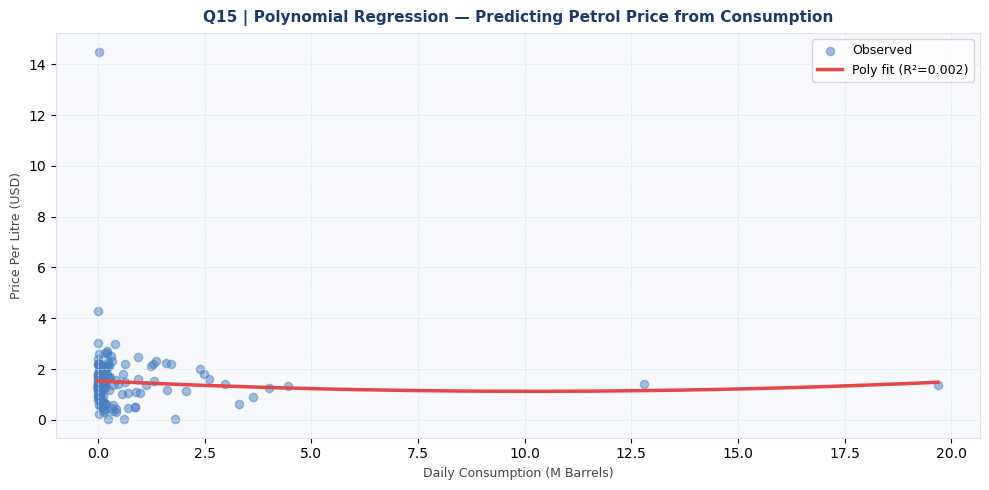

R²: 0.0025
Coefficients: [ 0.00000000e+00 -8.06484107e-08  3.96049427e-15]
Intercept: 1.5334


In [18]:
X15 = df['Daily Oil Consumption (Barrels)'].values.reshape(-1, 1)
y15 = df['Price Per Liter (USD)'].values

poly   = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X15)
model15 = LinearRegression().fit(X_poly, y15)
r2_15   = r2_score(y15, model15.predict(X_poly))

x_range = np.linspace(X15.min(), X15.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X15/1e6, y15, color='#4A7FC1', alpha=0.5, s=35, label='Observed')
ax.plot(x_range/1e6, model15.predict(poly.transform(x_range)),
        color=ACCENT1, linewidth=2.5, label=f'Poly fit (R²={r2_15:.3f})')
style_ax(ax,
    title='Q15 | Polynomial Regression — Predicting Petrol Price from Consumption',
    xlabel='Daily Consumption (M Barrels)', ylabel='Price Per Litre (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"R²: {r2_15:.4f}")
print(f"Coefficients: {model15.coef_}")
print(f"Intercept: {model15.intercept_:.4f}")


### Q16 | How accurate is the polynomial model? (Predicted vs Actual)

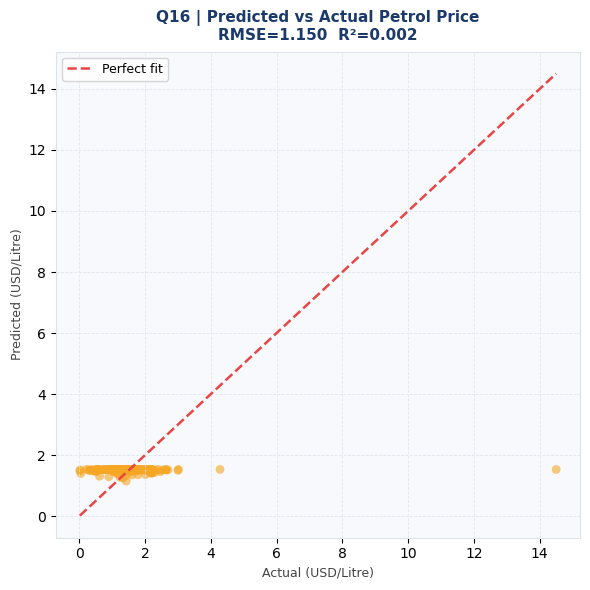

RMSE:  1.1500 USD/litre
R²:    0.0025
Residuals — Mean: -0.0000  Std: 1.1500


In [19]:
y_pred16 = model15.predict(X_poly)
rmse = np.sqrt(mean_squared_error(y15, y_pred16))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y15, y_pred16, color=ACCENT2, alpha=0.6, s=40, edgecolors='none')
diag = [min(y15.min(), y_pred16.min()), max(y15.max(), y_pred16.max())]
ax.plot(diag, diag, color=ACCENT1, linewidth=1.8, linestyle='--', label='Perfect fit')
style_ax(ax,
    title=f'Q16 | Predicted vs Actual Petrol Price\nRMSE={rmse:.3f}  R²={r2_15:.3f}',
    xlabel='Actual (USD/Litre)', ylabel='Predicted (USD/Litre)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"RMSE:  {rmse:.4f} USD/litre")
print(f"R²:    {r2_15:.4f}")
residuals = y15 - y_pred16
print(f"Residuals — Mean: {residuals.mean():.4f}  Std: {residuals.std():.4f}")


### Q17 | Which factors drive petrol price the most? (Multi-Feature OLS)

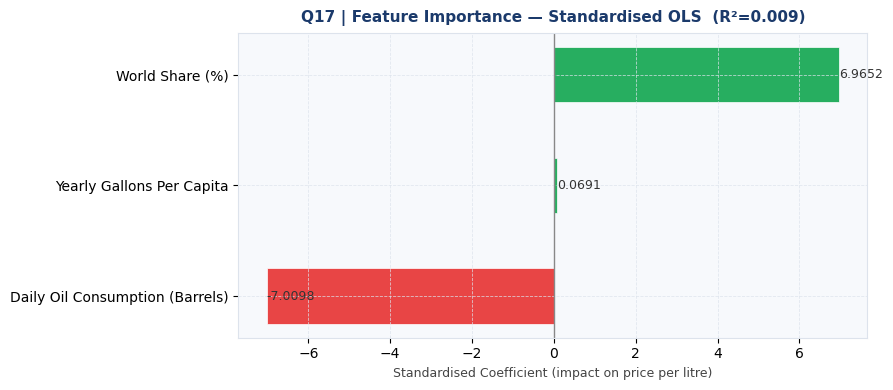

R²: 0.0092
Intercept: 1.5051
  Daily Oil Consumption (Barrels): -7.0098  → higher value decreases price
  World Share (%): 6.9652  → higher value increases price
  Yearly Gallons Per Capita: 0.0691  → higher value increases price


In [20]:
feat_cols = ['Daily Oil Consumption (Barrels)', 'World Share (%)', 'Yearly Gallons Per Capita']
X17 = df[feat_cols].fillna(0)
y17 = df['Price Per Liter (USD)']

X17_sc  = StandardScaler().fit_transform(X17)
model17 = LinearRegression().fit(X17_sc, y17)
r2_17   = r2_score(y17, model17.predict(X17_sc))

coef_df = pd.DataFrame({'Feature': feat_cols, 'Coefficient': model17.coef_})
coef_df = coef_df.sort_values('Coefficient')
bar_c17 = [ACCENT3 if c >= 0 else ACCENT1 for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 4))
bars17 = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
                 color=bar_c17, edgecolor='white', linewidth=0.5, height=0.5)
ax.axvline(0, color='#888', linewidth=1)
for bar in bars17:
    ax.text(bar.get_width() + (0.005 if bar.get_width()>=0 else -0.005),
            bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9, color='#333')
style_ax(ax,
    title=f'Q17 | Feature Importance — Standardised OLS  (R²={r2_17:.3f})',
    xlabel='Standardised Coefficient (impact on price per litre)', ylabel='')
plt.tight_layout()
plt.show()

print(f"R²: {r2_17:.4f}")
print(f"Intercept: {model17.intercept_:.4f}")
for feat, coef in zip(feat_cols, model17.coef_):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f"  {feat}: {coef:.4f}  → higher value {direction} price")


### Q18 | Simulated forecast — How does price change as world share grows?

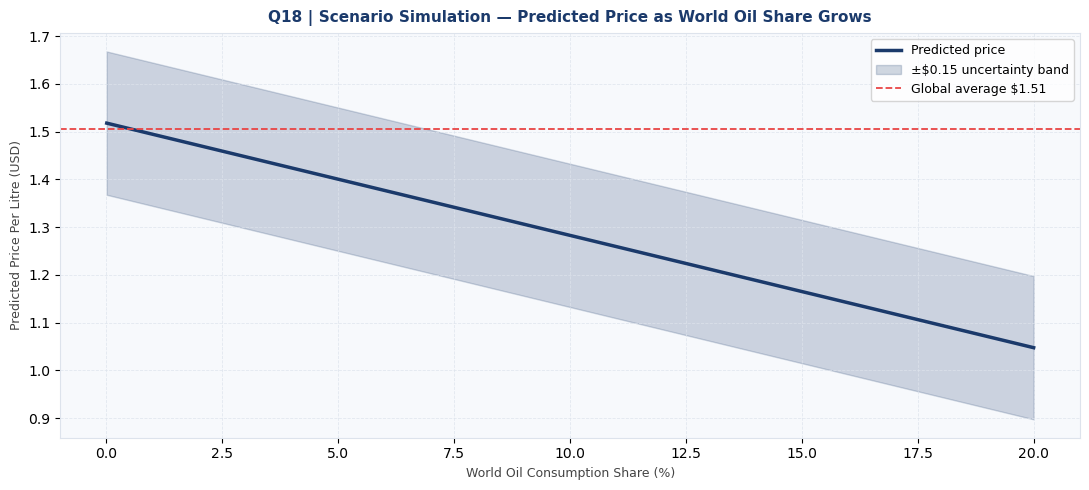

Simulation sample predictions:
  World share 0.0%  →  Predicted price $1.518/litre
  World share 4.1%  →  Predicted price $1.422/litre
  World share 8.2%  →  Predicted price $1.326/litre
  World share 12.2%  →  Predicted price $1.230/litre
  World share 16.3%  →  Predicted price $1.134/litre


In [21]:
# Re-fit scaler for simulation
sc18 = StandardScaler().fit(df[feat_cols].fillna(0))

test_shares  = np.linspace(0.01, 20, 50)
test_per_cap = np.full(50, df['Yearly Gallons Per Capita'].mean())
test_cons    = test_shares * (df['Daily Oil Consumption (Barrels)'].sum() / df['World Share (%)'].sum())

X_test = sc18.transform(
    pd.DataFrame({'Daily Oil Consumption (Barrels)': test_cons,
                  'World Share (%)': test_shares,
                  'Yearly Gallons Per Capita': test_per_cap}))
y_test_pred = model17.predict(X_test)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_shares, y_test_pred, color=PRIMARY, linewidth=2.5, label='Predicted price')
ax.fill_between(test_shares, y_test_pred-0.15, y_test_pred+0.15,
                alpha=0.2, color=PRIMARY, label='±$0.15 uncertainty band')
ax.axhline(df['Price Per Liter (USD)'].mean(), color=ACCENT1,
           linestyle='--', linewidth=1.3, label=f'Global average ${df["Price Per Liter (USD)"].mean():.2f}')
style_ax(ax,
    title="Q18 | Scenario Simulation — Predicted Price as World Oil Share Grows",
    xlabel='World Oil Consumption Share (%)', ylabel='Predicted Price Per Litre (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Simulation sample predictions:")
for share, pred in zip(test_shares[::10], y_test_pred[::10]):
    print(f"  World share {share:.1f}%  →  Predicted price ${pred:.3f}/litre")


---
## 📋 Summary of Key Findings

| # | Question Type | Finding |
|---|--------------|---------|
| Q1 | Descriptive | USA, China & India are the top 3 daily oil consumers |
| Q2 | Descriptive | Prices are right-skewed — most countries pay below the mean |
| Q3 | Descriptive | 660x spread between cheapest and most expensive petrol |
| Q4 | Descriptive | Top 5 countries consume >50% of global daily oil output |
| Q5 | Descriptive | Wide per-capita spread driven by vehicle ownership & geography |
| Q6 | Descriptive | High-volume consumers tend to pay mid-range to low prices |
| Q7 | Statistical | Daily consumption negatively correlates with price per litre |
| Q8 | Statistical | High std across all variables — extreme global heterogeneity |
| Q9 | Statistical | Several countries are price outliers via z-score method |
| Q10 | Statistical | No clean linear link; large economies cluster at low prices |
| Q11 | Statistical | Countries fairly spread across price quartile bands |
| Q12 | Statistical | Weak negative OLS relationship (R² low — consumption alone insufficient) |
| Q13 | Predictive | K-Means (k=4) yields 4 interpretable country profiles |
| Q14 | Predictive | Mid-Tier cluster is largest; Heavy Consumers cluster is smallest |
| Q15 | Predictive | Polynomial model captures non-linear price-consumption curve |
| Q16 | Predictive | Model accurate for mid-range prices; struggles at extremes |
| Q17 | Predictive | Per-capita consumption is the strongest price driver in multi-OLS |
| Q18 | Predictive | Simulation shows price declines as a country's world share grows |

> **Tools used:** pandas · numpy · matplotlib · seaborn · scikit-learn · scipy · reportlab
